# CyrusOne Data-Center Hearings

## 0. Environment

The core notebook needs `pandas`, `numpy`, `scipy`, `scikit-learn`, and `matplotlib`. `pyarrow`, `empath`, and `vaderSentiment` are optional. Uncomment the install command only when your environment is missing packages, then restart the kernel if Jupyter asks.

In [1]:
# Uncomment only if needed.
# import sys, subprocess
# subprocess.check_call([
#     sys.executable, "-m", "pip", "install", "-U",
#     "pandas", "numpy", "scipy", "scikit-learn", "matplotlib",
#     "pyarrow", "openpyxl", "empath", "vaderSentiment"
# ])

In [2]:
from __future__ import annotations

from pathlib import Path
from collections import Counter
from itertools import combinations
import hashlib
import json
import math
import os
import platform
import random
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    ENGLISH_STOP_WORDS,
)

pd.set_option("display.max_colwidth", 220)
pd.set_option("display.max_columns", 100)

RANDOM_SEED = 20260818
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())

Python: 3.13.3
Platform: macOS-26.5.1-arm64-arm-64bit-Mach-O


## 1. Project configuration and hearing manifest

Place this notebook in the same project directory as the `whisperx_outputs/` folder created by the transcription notebook. The preferred input is `*_segments.csv`; full `*_whisperx.json` and plain `*_transcript.txt` files are supported as fallbacks.

The two initial rows below use the stems already associated with the two hearings. Edit the generated `hearing_manifest.csv` to change titles, filenames, audio paths, or analysis time bounds. The notebook never overwrites an existing manifest.

In [3]:
BASE_DIR = Path.cwd()

# IMPORTANT: use the new diarized outputs
WHISPERX_DIR = BASE_DIR / "whisperx_outputs_diarized"

ANALYSIS_DIR = BASE_DIR / "SPFLD_data_center_analysis"
DATA_DIR = ANALYSIS_DIR / "data"
TABLES_DIR = ANALYSIS_DIR / "tables"
FIGURES_DIR = ANALYSIS_DIR / "figures"
ANNOTATIONS_DIR = ANALYSIS_DIR / "annotations"
LOGS_DIR = ANALYSIS_DIR / "logs"

for directory in [
    ANALYSIS_DIR,
    DATA_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    ANNOTATIONS_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = ANALYSIS_DIR / "hearing_manifest.csv"

INITIAL_HEARINGS = [
    {
        "hearing_id": "h1_2025_12_03",
        "date": "2025-12-03",
        "title": "Data-center hearing — December 3, 2025",
        "government_body": "",
        "project_name": "CyrusOne",
        "stem": "Cyrusone_Hearing_12032025",
        "segments_file": "Cyrusone_Hearing_12032025_segments.csv",
        "json_file": "Cyrusone_Hearing_12032025_whisperx.json",
        "transcript_file": "Cyrusone_Hearing_12032025_transcript.txt",
        "audio_file": "CyrusOne/Cyrusone_Hearing_12032025.mp3",
        "analysis_start_seconds": "",
        "analysis_end_seconds": "",
        "notes": "",
    },
    {
        "hearing_id": "h2_2026_03_23",
        "date": "2026-03-23",
        "title": "Data-center hearing — March 23, 2026",
        "government_body": "",
        "project_name": "CyrusOne",
        "stem": "COB_20260323_Imported",
        "segments_file": "COB_20260323_Imported_segments.csv",
        "json_file": "COB_20260323_Imported_whisperx.json",
        "transcript_file": "COB_20260323_Imported_transcript.txt",
        "audio_file": "CyrusOne/COB_20260323_Imported.mp3",
        "analysis_start_seconds": "",
        "analysis_end_seconds": "",
        "notes": "",
    },
]

# During development, make INITIAL_HEARINGS authoritative.
pd.DataFrame(INITIAL_HEARINGS).to_csv(
    MANIFEST_PATH,
    index=False,
)

hearing_manifest = (
    pd.read_csv(MANIFEST_PATH, dtype=str)
    .fillna("")
)

hearing_manifest["date"] = pd.to_datetime(
    hearing_manifest["date"],
    errors="coerce",
)

display(hearing_manifest)

# print("Base directory:  ", BASE_DIR)
# print("WhisperX inputs: ", WHISPERX_DIR)
print("Input directory exists:", WHISPERX_DIR.exists())

,hearing_id,date,title,government_body,project_name,stem,segments_file,json_file,transcript_file,audio_file,analysis_start_seconds,analysis_end_seconds,notes
0,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",,CyrusOne,Cyrusone_Hearing_12032025,Cyrusone_Hearing_12032025_segments.csv,Cyrusone_Hearing_12032025_whisperx.json,Cyrusone_Hearing_12032025_transcript.txt,CyrusOne/Cyrusone_Hearing_12032025.mp3,,,
1,h2_2026_03_23,2026-03-23,"Data-center hearing — March 23, 2026",,CyrusOne,COB_20260323_Imported,COB_20260323_Imported_segments.csv,COB_20260323_Imported_whisperx.json,COB_20260323_Imported_transcript.txt,CyrusOne/COB_20260323_Imported.mp3,,,


Input directory exists: True


In [4]:
# print("Looking in:")
# print(WHISPERX_DIR.resolve())

print("\nFiles found:")
for p in sorted(WHISPERX_DIR.glob("*")):
    print("  ", p.name)


Files found:
   COB_20260323_Imported.mp3
   COB_20260323_Imported_aligned.json
   COB_20260323_Imported_asr.json
   COB_20260323_Imported_diarization.csv
   COB_20260323_Imported_run_metadata.json
   COB_20260323_Imported_segments.csv
   COB_20260323_Imported_speakers.txt
   COB_20260323_Imported_transcript.txt
   COB_20260323_Imported_whisperx.json
   COB_20260323_Imported_words.csv
   Cyrusone_Hearing_12032025.mp3
   Cyrusone_Hearing_12032025_aligned.json
   Cyrusone_Hearing_12032025_asr.json
   Cyrusone_Hearing_12032025_diarization.csv
   Cyrusone_Hearing_12032025_run_metadata.json
   Cyrusone_Hearing_12032025_segments.csv
   Cyrusone_Hearing_12032025_speakers.txt
   Cyrusone_Hearing_12032025_transcript.txt
   Cyrusone_Hearing_12032025_whisperx.json
   Cyrusone_Hearing_12032025_words.csv
   diarization_qa.csv
   run_manifest.csv
   speaker_crosswalk_template.csv


## 2. Reusable helpers

These helpers keep exports auditable, preserve timestamps, and degrade gracefully when optional packages are unavailable.

In [5]:
def format_timestamp(seconds) -> str:
    """Convert seconds to HH:MM:SS.mmm; return blank for missing values."""
    if seconds is None or pd.isna(seconds):
        return ""
    milliseconds = int(round(float(seconds) * 1000))
    hours, remainder = divmod(milliseconds, 3_600_000)
    minutes, remainder = divmod(remainder, 60_000)
    secs, ms = divmod(remainder, 1_000)
    return f"{hours:02d}:{minutes:02d}:{secs:02d}.{ms:03d}"


def clean_whitespace(text) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()


def stable_hash(*parts, length: int = 16) -> str:
    raw = "||".join(str(p) for p in parts)
    return hashlib.sha1(raw.encode("utf-8")).hexdigest()[:length]


def parse_optional_float(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    text = str(value).strip()
    if not text:
        return None
    return float(text)


def parse_optional_bool(value):
    if value is None or pd.isna(value):
        return pd.NA
    text = str(value).strip().lower()
    if text in {"", "na", "n/a", "none"}:
        return pd.NA
    if text in {"1", "true", "t", "yes", "y"}:
        return True
    if text in {"0", "false", "f", "no", "n"}:
        return False
    raise ValueError(f"Cannot parse boolean value: {value!r}")


def first_existing(columns, candidates):
    lower_map = {str(c).lower(): c for c in columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None


def save_table(df: pd.DataFrame, stem: str, directory: Path = TABLES_DIR) -> dict:
    """Always save CSV; save Parquet when an engine is available."""
    directory.mkdir(parents=True, exist_ok=True)
    csv_path = directory / f"{stem}.csv"
    df.to_csv(csv_path, index=False)
    paths = {"csv": str(csv_path)}
    try:
        parquet_path = directory / f"{stem}.parquet"
        df.to_parquet(parquet_path, index=False)
        paths["parquet"] = str(parquet_path)
    except Exception:
        pass
    return paths


def package_snapshot() -> dict:
    packages = {}
    for name in ["numpy", "pandas", "scipy", "sklearn", "matplotlib"]:
        try:
            module = __import__(name)
            packages[name] = getattr(module, "__version__", "unknown")
        except Exception as exc:
            packages[name] = f"unavailable: {exc!r}"
    return {
        "python": sys.version,
        "platform": platform.platform(),
        "packages": packages,
        "random_seed": RANDOM_SEED,
    }

(LOGS_DIR / "environment_snapshot.json").write_text(
    json.dumps(package_snapshot(), indent=2), encoding="utf-8"
)


def update_annotation_template(path: Path, seed: pd.DataFrame, key_cols: list[str]) -> pd.DataFrame:
    """Create an annotation CSV or append newly discovered rows without overwriting edits."""
    seed = seed.copy()
    for key in key_cols:
        if key not in seed.columns:
            raise ValueError(f"Seed table is missing key column {key!r} for {path.name}.")

    if not path.exists():
        seed.to_csv(path, index=False)
        print("Created:", path)
        return pd.read_csv(path, dtype=str).fillna("")

    existing = pd.read_csv(path, dtype=str).fillna("")
    missing_keys = set(key_cols) - set(existing.columns)
    if missing_keys:
        raise ValueError(f"{path.name} is missing key columns: {sorted(missing_keys)}")

    all_cols = list(dict.fromkeys([*existing.columns, *seed.columns]))
    for col in all_cols:
        if col not in existing.columns:
            existing[col] = ""
        if col not in seed.columns:
            seed[col] = ""
    existing = existing[all_cols]
    seed = seed[all_cols]

    def keys(df: pd.DataFrame) -> pd.Series:
        return df[key_cols].astype(str).agg("||".join, axis=1)

    existing_key_values = set(keys(existing))
    new_rows = seed[~keys(seed).isin(existing_key_values)].copy()
    if not new_rows.empty:
        existing = pd.concat([existing, new_rows], ignore_index=True)
        existing.to_csv(path, index=False)
        print(f"Appended {len(new_rows)} new row(s) to: {path}")

    if existing.duplicated(key_cols).any():
        warnings.warn(f"Duplicate annotation keys found in {path.name}; review {key_cols}.")
    return existing.fillna("")


## 3. Load and normalize WhisperX outputs

Input priority is:

1. aligned segment CSV;
2. full WhisperX JSON;
3. plain transcript text.

Plain text can support LDA and dictionaries, but it cannot support precise speaker or audio attribution. The audit table below makes those limitations visible rather than silently filling them in.

In [6]:
def resolve_user_path(value: str, default_dir: Path) -> Path | None:
    text = str(value or "").strip()
    if not text:
        return None
    path = Path(text).expanduser()
    if not path.is_absolute():
        path = default_dir / path
    return path


def case_insensitive_match(directory: Path, filename: str) -> Path | None:
    if not directory.exists():
        return None
    target = filename.lower()
    for path in directory.iterdir():
        if path.is_file() and path.name.lower() == target:
            return path
    return None


def discover_input(row: pd.Series) -> tuple[Path, str]:
    explicit = [
        ("segments", resolve_user_path(row.get("segments_file", ""), WHISPERX_DIR)),
        ("json", resolve_user_path(row.get("json_file", ""), WHISPERX_DIR)),
        ("transcript", resolve_user_path(row.get("transcript_file", ""), WHISPERX_DIR)),
    ]
    for kind, path in explicit:
        if path and path.exists():
            return path, kind

    stem = str(row.get("stem", "")).strip()
    candidates = [
        ("segments", f"{stem}_segments.csv"),
        ("json", f"{stem}_whisperx.json"),
        ("transcript", f"{stem}_transcript.txt"),
    ]
    for kind, filename in candidates:
        path = case_insensitive_match(WHISPERX_DIR, filename)
        if path:
            return path, kind

    # Looser match, useful when a filename has an extra suffix.
    if WHISPERX_DIR.exists() and stem:
        ranked = []
        for path in WHISPERX_DIR.iterdir():
            if not path.is_file() or stem.lower() not in path.name.lower():
                continue
            if path.name.lower().endswith("_segments.csv"):
                rank, kind = 0, "segments"
            elif path.name.lower().endswith("_whisperx.json"):
                rank, kind = 1, "json"
            elif path.name.lower().endswith("_transcript.txt"):
                rank, kind = 2, "transcript"
            else:
                continue
            ranked.append((rank, path.name.lower(), path, kind))
        if ranked:
            _, _, path, kind = sorted(ranked)[0]
            return path, kind

    raise FileNotFoundError(
        f"No WhisperX output found for hearing_id={row['hearing_id']!r}, stem={stem!r}. "
        f"Expected files under {WHISPERX_DIR}."
    )


def load_segment_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    text_col = first_existing(df.columns, ["text", "transcript", "segment_text", "caption"])
    if text_col is None:
        raise ValueError(f"No text column found in {path.name}. Columns: {list(df.columns)}")
    start_col = first_existing(df.columns, ["start", "start_seconds", "segment_start"])
    end_col = first_existing(df.columns, ["end", "end_seconds", "segment_end"])
    speaker_col = first_existing(df.columns, ["speaker", "speaker_id", "speaker_label"])
    segment_col = first_existing(df.columns, ["segment_id", "id", "index"])

    out = pd.DataFrame({
        "segment_id_original": df[segment_col] if segment_col else np.arange(len(df)),
        "start_seconds": pd.to_numeric(df[start_col], errors="coerce") if start_col else np.nan,
        "end_seconds": pd.to_numeric(df[end_col], errors="coerce") if end_col else np.nan,
        "speaker_cluster": df[speaker_col].astype("string") if speaker_col else pd.Series(pd.NA, index=df.index, dtype="string"),
        "raw_text": df[text_col].map(clean_whitespace),
    })
    return out


def load_whisper_json(path: Path) -> pd.DataFrame:
    obj = json.loads(path.read_text(encoding="utf-8"))
    segments = obj.get("segments", [])
    rows = []
    for i, segment in enumerate(segments):
        rows.append({
            "segment_id_original": i,
            "start_seconds": segment.get("start"),
            "end_seconds": segment.get("end"),
            "speaker_cluster": segment.get("speaker"),
            "raw_text": clean_whitespace(segment.get("text", "")),
        })
    return pd.DataFrame(rows)


def load_plain_transcript(path: Path) -> pd.DataFrame:
    lines = [clean_whitespace(line) for line in path.read_text(encoding="utf-8").splitlines()]
    lines = [line for line in lines if line]
    if not lines:
        text = clean_whitespace(path.read_text(encoding="utf-8"))
        lines = [text] if text else []
    return pd.DataFrame({
        "segment_id_original": np.arange(len(lines)),
        "start_seconds": np.nan,
        "end_seconds": np.nan,
        "speaker_cluster": pd.Series(pd.NA, index=range(len(lines)), dtype="string"),
        "raw_text": lines,
    })


def load_hearing(row: pd.Series) -> pd.DataFrame:
    path, kind = discover_input(row)
    if kind == "segments":
        df = load_segment_csv(path)
    elif kind == "json":
        df = load_whisper_json(path)
    else:
        df = load_plain_transcript(path)

    df = df[df["raw_text"].str.len().gt(0)].copy().reset_index(drop=True)
    df["hearing_id"] = row["hearing_id"]
    df["date"] = row["date"]
    df["title"] = row["title"]
    df["input_path"] = str(path)
    df["input_format"] = kind
    df["segment_index"] = np.arange(len(df))
    df["speaker_cluster"] = (
        df["speaker_cluster"]
        .astype("string")
        .fillna("UNKNOWN")
        .replace({"": "UNKNOWN", "nan": "UNKNOWN", "None": "UNKNOWN"})
    )

    lower = parse_optional_float(row.get("analysis_start_seconds", ""))
    upper = parse_optional_float(row.get("analysis_end_seconds", ""))
    if lower is not None and df["end_seconds"].notna().any():
        df = df[df["end_seconds"].fillna(df["start_seconds"]).ge(lower)]
    if upper is not None and df["start_seconds"].notna().any():
        df = df[df["start_seconds"].le(upper)]

    df["segment_id"] = [
        f"{row['hearing_id']}_s{i:05d}" for i in range(len(df))
    ]
    return df.reset_index(drop=True)


loaded = []
load_failures = []
for _, row in hearing_manifest.iterrows():
    try:
        loaded.append(load_hearing(row))
    except Exception as exc:
        load_failures.append({"hearing_id": row["hearing_id"], "error": repr(exc)})

if not loaded:
    discovered = sorted(str(p) for p in WHISPERX_DIR.glob("*") if p.is_file()) if WHISPERX_DIR.exists() else []
    raise FileNotFoundError(
        "No hearing transcripts could be loaded. Edit hearing_manifest.csv or place WhisperX outputs "
        f"under {WHISPERX_DIR}. Discovered files: {discovered}"
    )

segments = pd.concat(loaded, ignore_index=True)
segments["n_words"] = segments["raw_text"].str.findall(r"\b\w+\b").str.len()
segments["duration_seconds"] = segments["end_seconds"] - segments["start_seconds"]
segments["start_timestamp"] = segments["start_seconds"].map(format_timestamp)
segments["end_timestamp"] = segments["end_seconds"].map(format_timestamp)

save_table(segments, "01_normalized_segments", DATA_DIR)

if load_failures:
    display(Markdown("### Input warnings"))
    display(pd.DataFrame(load_failures))

display(segments.head(12))

,segment_id_original,start_seconds,end_seconds,speaker_cluster,raw_text,hearing_id,date,title,input_path,input_format,segment_index,segment_id,n_words,duration_seconds,start_timestamp,end_timestamp
0,0,0.740,1.941,SPEAKER_12,THE BOARD WILL COME TO ORDER.,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,0,h1_2025_12_03_s00000,6,1.201,00:00:00.740,00:00:01.941
1,1,3.301,5.102,SPEAKER_12,INVOCATION BY MS. FULGENZI.,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,1,h1_2025_12_03_s00001,4,1.801,00:00:03.301,00:00:05.102
2,2,5.982,7.662,SPEAKER_12,PLEDGE OF ALLEGIANCE BY MR. CHUMMELIN.,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,2,h1_2025_12_03_s00002,6,1.680,00:00:05.982,00:00:07.662
3,3,7.682,15.565,SPEAKER_16,"DEVON, FOLLOW ME OUT.",h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,3,h1_2025_12_03_s00003,4,7.883,00:00:07.682,00:00:15.565
4,4,15.605,17.245,SPEAKER_41,PLEASE GUIDE US.,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,4,h1_2025_12_03_s00004,3,1.640,00:00:15.605,00:00:17.245
5,5,17.746,23.287,SPEAKER_41,PLEASE HELP US TO SHOW OUR NEIGHBORS COMPASSION AND GRACE AND ALL THOSE THAT WE AGREE WITH OR DISAGREE WITH.,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,5,h1_2025_12_03_s00005,20,5.541,00:00:17.746,00:00:23.287
6,6,24.028,28.589,SPEAKER_41,PLEASE HELP US ALL TO LISTEN AND TO LEARN TONIGHT SO THAT WE MAY MAKE THE BEST CHOICES FOR OUR COMMUNITY.,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,6,h1_2025_12_03_s00006,21,4.561,00:00:24.028,00:00:28.589
7,7,30.087,35.011,SPEAKER_41,"And dear Lord, please bless everyone in this room and our community as we go into the holiday season.",h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,7,h1_2025_12_03_s00007,19,4.924,00:00:30.087,00:00:35.011
8,8,35.071,39.274,SPEAKER_41,"May everyone enjoy faith, family, and this season.",h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,8,h1_2025_12_03_s00008,8,4.203,00:00:35.071,00:00:39.274
9,9,39.754,39.934,SPEAKER_41,Amen.,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,9,h1_2025_12_03_s00009,1,0.180,00:00:39.754,00:00:39.934


In [7]:
def non_unknown_speakers(series: pd.Series) -> int:
    values = set(series.dropna().astype(str)) - {"UNKNOWN", "", "nan", "None"}
    return len(values)

segment_audit = (
    segments.groupby(["hearing_id", "title", "input_path", "input_format"], dropna=False)
    .agg(
        n_segments=("segment_id", "size"),
        n_words=("n_words", "sum"),
        first_start=("start_seconds", "min"),
        last_end=("end_seconds", "max"),
        timed_segments=("start_seconds", lambda s: int(s.notna().sum())),
        speaker_clusters=("speaker_cluster", non_unknown_speakers),
    )
    .reset_index()
)
segment_audit["approx_duration_minutes"] = (
    segment_audit["last_end"] - segment_audit["first_start"]
) / 60
segment_audit["diarization_available"] = segment_audit["speaker_clusters"].ge(2)

save_table(segment_audit, "02_input_audit")
display(segment_audit)

for row in segment_audit.itertuples(index=False):
    if not row.diarization_available:
        print(
            f"WARNING: {row.hearing_id} does not contain usable multi-speaker diarization. "
            "The notebook will use sentence windows for NLP and will not treat machine segments as public comments."
        )
    if row.timed_segments == 0:
        print(
            f"WARNING: {row.hearing_id} has no timestamps. Quote and audio audit fields will remain incomplete."
        )

,hearing_id,title,input_path,input_format,n_segments,n_words,first_start,last_end,timed_segments,speaker_clusters,approx_duration_minutes,diarization_available
0,h1_2025_12_03,"Data-center hearing — December 3, 2025",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,segments,3350,44301,0.740,17271.779,3350,48,287.850650,True
1,h2_2026_03_23,"Data-center hearing — March 23, 2026",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/COB_20260323_Imported_segments.csv,segments,2888,34717,0.945,14144.005,2888,79,235.717667,True


## 4. Transcript and speaker audits

The next cells create two non-destructive annotation files:

- `transcript_audit_sample.csv` — a stratified sample for checking names, technical terms, negation, speaker identity, and exact wording against the audio;
- `speaker_crosswalk.csv` — one row per anonymous diarization cluster, with sample text and blank fields for the speaker's name and role.

Edit these files outside the notebook and rerun from this section. Existing annotations are never overwritten.

In [8]:
TRANSCRIPT_AUDIT_PATH = ANNOTATIONS_DIR / "transcript_audit_sample.csv"

audit_rows = []
for hearing_id, group in segments.groupby("hearing_id", sort=False):
    n = min(12, len(group))
    if n == 0:
        continue
    # Spread the sample over the hearing instead of taking a random cluster.
    indices = np.unique(np.linspace(0, len(group) - 1, n).round().astype(int))
    audit_rows.append(group.iloc[indices].copy())

audit = pd.concat(audit_rows, ignore_index=True) if audit_rows else segments.head(0).copy()
audit = audit[[
    "hearing_id", "segment_id", "start_timestamp", "end_timestamp",
    "speaker_cluster", "raw_text", "input_path"
]].copy()
audit["human_text"] = ""
audit["speaker_correct"] = ""
audit["names_correct"] = ""
audit["technical_terms_correct"] = ""
audit["negation_correct"] = ""
audit["audio_verified"] = ""
audit["error_notes"] = ""

transcript_audit = update_annotation_template(
    TRANSCRIPT_AUDIT_PATH, audit, ["hearing_id", "segment_id"]
)
display(transcript_audit.head(12))

,hearing_id,segment_id,start_timestamp,end_timestamp,speaker_cluster,raw_text,input_path,human_text,speaker_correct,names_correct,technical_terms_correct,negation_correct,audio_verified,error_notes
0,h1_2025_12_03,h1_2025_12_03_s00000,00:00:00.740,00:00:01.941,SPEAKER_12,THE BOARD WILL COME TO ORDER.,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
1,h1_2025_12_03,h1_2025_12_03_s00304,00:27:25.706,00:27:26.146,SPEAKER_14,Thank you.,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
2,h1_2025_12_03,h1_2025_12_03_s00609,00:53:26.622,00:53:28.205,SPEAKER_09,It looked like it was just empty space.,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
3,h1_2025_12_03,h1_2025_12_03_s00913,01:16:16.785,01:16:17.265,SPEAKER_20,I'm going.,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
4,h1_2025_12_03,h1_2025_12_03_s01218,01:50:18.509,01:50:26.791,SPEAKER_04,"that was just passed gives ICC the power to regulate rates, what type of power, and what we procure.",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
5,h1_2025_12_03,h1_2025_12_03_s01522,02:12:13.582,02:12:16.224,SPEAKER_25,"Now, if he wants to finish that on your time, please.",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
6,h1_2025_12_03,h1_2025_12_03_s01827,02:38:49.767,02:38:51.708,SPEAKER_23,NEXT SLIDE.,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
7,h1_2025_12_03,h1_2025_12_03_s02131,03:02:19.298,03:02:36.473,SPEAKER_15,"If during the time that these zoning rules exist, Cyrus 1 substantially relies on those and spends enough money or time or what have you, they can get a vested right in proceeding forward under the existing rules.",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
8,h1_2025_12_03,h1_2025_12_03_s02436,03:27:52.381,03:27:55.163,SPEAKER_09,"So in other words, if your electric supply was totally",/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,
9,h1_2025_12_03,h1_2025_12_03_s02740,03:54:45.550,03:54:47.171,SPEAKER_45,About 280 acres.,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,,,,,,,


In [9]:
SPEAKER_CROSSWALK_PATH = ANNOTATIONS_DIR / "speaker_crosswalk.csv"
ALLOWED_SPEAKER_ROLES = {
    "public", "official", "staff", "developer", "consultant", "media", "other", "unknown", ""
}

speaker_seed = (
    segments.groupby(["hearing_id", "speaker_cluster"], dropna=False)
    .agg(
        n_segments=("segment_id", "size"),
        n_words=("n_words", "sum"),
        first_start_seconds=("start_seconds", "min"),
        sample_text=("raw_text", lambda s: " | ".join(s.head(4))[:700]),
    )
    .reset_index()
)
speaker_seed["first_timestamp"] = speaker_seed["first_start_seconds"].map(format_timestamp)
speaker_seed["speaker_name"] = ""
speaker_seed["speaker_role"] = ""
speaker_seed["organization"] = ""
speaker_seed["confidence"] = ""
speaker_seed["notes"] = ""

speaker_crosswalk = update_annotation_template(
    SPEAKER_CROSSWALK_PATH,
    speaker_seed,
    ["hearing_id", "speaker_cluster"],
)
required_crosswalk = {"hearing_id", "speaker_cluster", "speaker_name", "speaker_role"}
if not required_crosswalk.issubset(speaker_crosswalk.columns):
    raise ValueError(f"speaker_crosswalk.csv must contain {sorted(required_crosswalk)}")

bad_roles = sorted(
    set(speaker_crosswalk["speaker_role"].str.strip().str.lower()) - ALLOWED_SPEAKER_ROLES
)
if bad_roles:
    raise ValueError(f"Unrecognized speaker roles: {bad_roles}. Allowed: {sorted(ALLOWED_SPEAKER_ROLES)}")

speaker_crosswalk["speaker_role"] = speaker_crosswalk["speaker_role"].str.strip().str.lower()
display(speaker_crosswalk)

,hearing_id,speaker_cluster,n_segments,n_words,first_start_seconds,sample_text,first_timestamp,speaker_name_guess,speaker_role,organization,confidence,notes,speaker_name
0,h1_2025_12_03,SPEAKER_00,8,69,3652.184,"My question is for Brad. | As far as the generators, are they gas or diesel? | I'm just asking for like a sound. | They're diesel.",00:52.2,,official,Sangamon County Board,medium,,
1,h1_2025_12_03,SPEAKER_01,31,415,17101.564,"I'm Brianna Day. | I don't know which district I live in because I've been homeless, so that's cool. | So I know I'm not allowed to ask questions, so I'm just going to put them out into the universe and have somebody...",45:01.6,Brianna Day,public,,high,,
2,h1_2025_12_03,SPEAKER_02,23,395,16488.586,"Hi, my name is Wes Carney, and I grew up in a farm about four miles from the proposed site. | And I have some questions. | There was a lot of commentary about the generators and running the diesel engines and stuff l...",34:48.6,Wes Carney,public,,high,,
3,h1_2025_12_03,SPEAKER_03,4,147,12306.229,"All right. | County Board Member Reggie Guyton, thank you so much for that follow-up question. | I know I've had several one-on-one meetings and also have started having conversations in regard to the PLA, and that w...",25:06.2,,official,Sangamon County Board,medium,,
4,h1_2025_12_03,SPEAKER_04,12,220,6560.628,"I've been receiving a lot of letters from businesses, and they've been using Cyrus One's form letter to the T, except the only difference is the letterhead and the signature at the bottom. | However, CWLP, they're in...",49:20.6,,official,Sangamon County Board,medium,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,h2_2026_03_23,SPEAKER_75,19,249,10160.02,Hello. | My name is Dalton Ioka. | I'm a lifelong resident of Sangamon County. | I'm a part of a family of farmers of eight generations.,49:20.0,Dalton Ioka,public,,high,,
125,h2_2026_03_23,SPEAKER_76,21,210,0.945,"We ask of you this evening to help us in our decisions for the community, for all of our people, based on the sound advice and information given to us, for a safe and economically viable county. | We know that you wi...",00:00.9,,public,International Union of Operating Engineers Local 965,medium,,
126,h2_2026_03_23,SPEAKER_77,7,119,9215.039,"Cyrus One is a multi-billion dollar corporation with a major private equity shareholder. | They don't care about us. | They only care about maximizing shareholder value, and as of late 2025, reports indicate Cyrus On...",33:35.0,,public,,high,,
127,h2_2026_03_23,SPEAKER_78,21,187,8995.68,"I'm Shane Bettis, Kathy's husband, country boy born and bred. | She has to buy a | License for her kennel? | Commercial?",29:55.7,Shane Bettis,public,,high,,


## 5. Reconstruct speaker turns and substantive comments

A **turn** is a run of adjacent segments from the same diarized speaker, separated by no more than `MAX_GAP_WITHIN_TURN` seconds. Unknown speakers are not automatically merged because doing so would fabricate comment boundaries.

The notebook then creates `turn_review.csv`. Its optional fields let you:

- join non-adjacent turns into one `comment_group`;
- override a speaker name or role;
- assign an agenda section;
- mark procedural material;
- exclude irrelevant material.

The automatic procedural flag is deliberately conservative and should be reviewed rather than treated as ground truth.

In [10]:
MAX_GAP_WITHIN_TURN = 3.0

PROCEDURAL_PATTERNS = [
    r"\bcall (?:this|the) meeting to order\b",
    r"\broll call\b",
    r"\bmotion to\b",
    r"\bsecond(?:ed)? the motion\b",
    r"\ball in favor\b",
    r"\bmeeting (?:is )?adjourned\b",
    r"\bnext speaker\b",
    r"\bstate (?:and spell )?your name\b",
    r"\bplease come (?:up|forward)\b",
    r"\bpublic comment period\b",
    r"\byour (?:three|two|five) minutes\b",
    r"\btime has expired\b",
    r"\bturn on the microphone\b",
]
PROCEDURAL_RE = re.compile("|".join(PROCEDURAL_PATTERNS), re.IGNORECASE)


def procedural_auto(text: str) -> bool:
    text = clean_whitespace(text)
    n_words = len(re.findall(r"\b\w+\b", text))
    if PROCEDURAL_RE.search(text):
        return True
    if n_words <= 8 and re.fullmatch(
        r"(?i)(thank you|thanks|good evening|good afternoon|good morning|you may begin)[.! ]*",
        text,
    ):
        return True
    return False


def build_turns(segment_df: pd.DataFrame) -> pd.DataFrame:
    work = segment_df.sort_values(["hearing_id", "segment_index"]).copy()
    work["prev_speaker"] = work.groupby("hearing_id")["speaker_cluster"].shift()
    work["prev_end"] = work.groupby("hearing_id")["end_seconds"].shift()
    work["gap_seconds"] = work["start_seconds"] - work["prev_end"]

    same_speaker = work["speaker_cluster"].eq(work["prev_speaker"])
    known_speaker = work["speaker_cluster"].ne("UNKNOWN")
    small_gap = work["gap_seconds"].isna() | work["gap_seconds"].le(MAX_GAP_WITHIN_TURN)

    work["new_turn"] = (~same_speaker) | (~known_speaker) | (~small_gap)
    work.loc[work.groupby("hearing_id").head(1).index, "new_turn"] = True
    work["turn_number"] = work.groupby("hearing_id")["new_turn"].cumsum().astype(int)
    work["turn_id"] = (
        work["hearing_id"].astype(str)
        + "_t"
        + work["turn_number"].astype(str).str.zfill(5)
    )

    turns = (
        work.groupby(["hearing_id", "turn_id"], sort=False, dropna=False)
        .agg(
            date=("date", "first"),
            title=("title", "first"),
            speaker_cluster=("speaker_cluster", "first"),
            start_seconds=("start_seconds", "min"),
            end_seconds=("end_seconds", "max"),
            n_segments=("segment_id", "size"),
            raw_text=("raw_text", lambda s: clean_whitespace(" ".join(s))),
            source_segment_ids=("segment_id", lambda s: "|".join(s.astype(str))),
            input_path=("input_path", "first"),
        )
        .reset_index()
    )
    turns["n_words"] = turns["raw_text"].str.findall(r"\b\w+\b").str.len()
    turns["duration_seconds"] = turns["end_seconds"] - turns["start_seconds"]
    turns["start_timestamp"] = turns["start_seconds"].map(format_timestamp)
    turns["end_timestamp"] = turns["end_seconds"].map(format_timestamp)
    turns["procedural_auto"] = turns["raw_text"].map(procedural_auto)
    return turns


turns = build_turns(segments)
turns = turns.merge(
    speaker_crosswalk[[
        "hearing_id", "speaker_cluster", "speaker_name", "speaker_role", "organization"
    ]],
    on=["hearing_id", "speaker_cluster"],
    how="left",
)
for col in ["speaker_name", "speaker_role", "organization"]:
    turns[col] = turns[col].fillna("")

save_table(turns, "03_auto_turns", DATA_DIR)
display(turns.head(15))

,hearing_id,turn_id,date,title,speaker_cluster,start_seconds,end_seconds,n_segments,raw_text,source_segment_ids,input_path,n_words,duration_seconds,start_timestamp,end_timestamp,procedural_auto,speaker_name,speaker_role,organization
0,h1_2025_12_03,h1_2025_12_03_t00001,2025-12-03,"Data-center hearing — December 3, 2025",SPEAKER_12,0.740,7.662,3,THE BOARD WILL COME TO ORDER. INVOCATION BY MS. FULGENZI. PLEDGE OF ALLEGIANCE BY MR. CHUMMELIN.,h1_2025_12_03_s00000|h1_2025_12_03_s00001|h1_2025_12_03_s00002,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,16,6.922,00:00:00.740,00:00:07.662,False,,official,Sangamon County Board
1,h1_2025_12_03,h1_2025_12_03_t00002,2025-12-03,"Data-center hearing — December 3, 2025",SPEAKER_16,7.682,15.565,1,"DEVON, FOLLOW ME OUT.",h1_2025_12_03_s00003,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,4,7.883,00:00:07.682,00:00:15.565,False,,unknown,
2,h1_2025_12_03,h1_2025_12_03_t00003,2025-12-03,"Data-center hearing — December 3, 2025",SPEAKER_41,15.605,39.934,6,PLEASE GUIDE US. PLEASE HELP US TO SHOW OUR NEIGHBORS COMPASSION AND GRACE AND ALL THOSE THAT WE AGREE WITH OR DISAGREE WITH. PLEASE HELP US ALL TO LISTEN AND TO LEARN TONIGHT SO THAT WE MAY MAKE THE BEST CHOICES FOR...,h1_2025_12_03_s00004|h1_2025_12_03_s00005|h1_2025_12_03_s00006|h1_2025_12_03_s00007|h1_2025_12_03_s00008|h1_2025_12_03_s00009,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,72,24.329,00:00:15.605,00:00:39.934,False,,official,Sangamon County Board
3,h1_2025_12_03,h1_2025_12_03_t00004,2025-12-03,"Data-center hearing — December 3, 2025",SPEAKER_17,39.954,55.225,1,"I pledge allegiance to the flag of the United States of America and to the republic for which it stands, one nation, under God, indivisible, with liberty and justice for all.",h1_2025_12_03_s00010,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,31,15.271,00:00:39.954,00:00:55.225,False,,unknown,
4,h1_2025_12_03,h1_2025_12_03_t00005,2025-12-03,"Data-center hearing — December 3, 2025",SPEAKER_12,60.770,86.045,1,an announcement to the public we will be closing the sign-up sheet speak tonight thirty minutes into the program so if you want to sign up to speak tonight please go outside there's a sign-up sheet the clerk will cal...,h1_2025_12_03_s00011,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,58,25.275,00:01:00.770,00:01:26.045,False,,official,Sangamon County Board
5,h1_2025_12_03,h1_2025_12_03_t00006,2025-12-03,"Data-center hearing — December 3, 2025",SPEAKER_26,89.200,108.381,22,Excuse. Diener. Here. DelGiorno. Here. Steppe. Excuse. Douglas Williams. Here. Forsyth. Here. Frazee. Here. Fulgenzi. Here. Guyton. Excused. Hall. Here. Crell. Here. Lathan.,h1_2025_12_03_s00012|h1_2025_12_03_s00013|h1_2025_12_03_s00014|h1_2025_12_03_s00015|h1_2025_12_03_s00016|h1_2025_12_03_s00017|h1_2025_12_03_s00018|h1_2025_12_03_s00019|h1_2025_12_03_s00020|h1_2025_12_03_s00021|h1_202...,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,23,19.181,00:01:29.200,00:01:48.381,False,,staff,Sangamon County Clerk
6,h1_2025_12_03,h1_2025_12_03_t00007,2025-12-03,"Data-center hearing — December 3, 2025",SPEAKER_17,109.081,109.221,1,Here.,h1_2025_12_03_s00034,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,1,0.140,00:01:49.081,00:01:49.221,False,,unknown,
7,h1_2025_12_03,h1_2025_12_03_t00008,2025-12-03,"Data-center hearing — December 3, 2025",SPEAKER_26,110.321,115.963,5,Madonia. Here. McGuire. Excused. Mendenhall.,h1_2025_12_03_s00035|h1_2025_12_03_s00036|h1_2025_12_03_s00037|h1_2025_12_03_s0003

In [11]:
TURN_REVIEW_PATH = ANNOTATIONS_DIR / "turn_review.csv"

turn_review_seed = turns[[
    "hearing_id", "turn_id", "start_timestamp", "end_timestamp",
    "speaker_cluster", "speaker_name", "speaker_role", "raw_text", "procedural_auto"
]].copy()
turn_review_seed["comment_group"] = ""
turn_review_seed["speaker_name_override"] = ""
turn_review_seed["speaker_role_override"] = ""
turn_review_seed["agenda_section"] = ""
turn_review_seed["procedural_override"] = ""
turn_review_seed["include_override"] = ""
turn_review_seed["notes"] = ""

turn_review = update_annotation_template(
    TURN_REVIEW_PATH,
    turn_review_seed,
    ["hearing_id", "turn_id"],
)
review_cols = [
    "hearing_id", "turn_id", "comment_group", "speaker_name_override",
    "speaker_role_override", "agenda_section", "procedural_override",
    "include_override", "notes"
]
missing = set(review_cols) - set(turn_review.columns)
if missing:
    raise ValueError(f"turn_review.csv is missing columns: {sorted(missing)}")

turns_reviewed = turns.merge(turn_review[review_cols], on=["hearing_id", "turn_id"], how="left")
for col in review_cols[2:]:
    turns_reviewed[col] = turns_reviewed[col].fillna("")

turns_reviewed["speaker_name_final"] = turns_reviewed["speaker_name_override"].where(
    turns_reviewed["speaker_name_override"].str.strip().ne(""),
    turns_reviewed["speaker_name"],
)
turns_reviewed["speaker_role_final"] = turns_reviewed["speaker_role_override"].where(
    turns_reviewed["speaker_role_override"].str.strip().ne(""),
    turns_reviewed["speaker_role"],
).str.strip().str.lower().replace("", "unknown")

turns_reviewed["procedural_override_parsed"] = turns_reviewed["procedural_override"].map(parse_optional_bool)
turns_reviewed["include_override_parsed"] = turns_reviewed["include_override"].map(parse_optional_bool)
turns_reviewed["is_procedural"] = turns_reviewed["procedural_override_parsed"].where(
    turns_reviewed["procedural_override_parsed"].notna(),
    turns_reviewed["procedural_auto"],
).astype(bool)
turns_reviewed["include"] = turns_reviewed["include_override_parsed"].where(
    turns_reviewed["include_override_parsed"].notna(),
    True,
).astype(bool)

turns_reviewed["comment_key"] = turns_reviewed["comment_group"].str.strip()
turns_reviewed.loc[turns_reviewed["comment_key"].eq(""), "comment_key"] = turns_reviewed["turn_id"]


def joined_unique(values, default=""):
    cleaned = [str(v).strip() for v in values if str(v).strip() and str(v).strip().lower() != "nan"]
    unique = list(dict.fromkeys(cleaned))
    if not unique:
        return default
    return unique[0] if len(unique) == 1 else " | ".join(unique)


comments = (
    turns_reviewed.groupby(["hearing_id", "comment_key"], sort=False, dropna=False)
    .agg(
        date=("date", "first"),
        title=("title", "first"),
        start_seconds=("start_seconds", "min"),
        end_seconds=("end_seconds", "max"),
        speaker_cluster=("speaker_cluster", joined_unique),
        speaker_name=("speaker_name_final", joined_unique),
        speaker_role=("speaker_role_final", joined_unique),
        agenda_section=("agenda_section", joined_unique),
        raw_text=("raw_text", lambda s: clean_whitespace(" ".join(s))),
        source_turn_ids=("turn_id", lambda s: "|".join(s.astype(str))),
        source_segment_ids=("source_segment_ids", lambda s: "|".join(s.astype(str))),
        input_path=("input_path", "first"),
        is_procedural=("is_procedural", "all"),
        include=("include", "all"),
    )
    .reset_index()
    .rename(columns={"comment_key": "comment_id"})
)
comments["speaker_role"] = comments["speaker_role"].replace("", "unknown")
comments["speaker_name"] = comments["speaker_name"].replace("", "Unknown speaker")
comments["agenda_section"] = comments["agenda_section"].replace("", "unassigned")
comments["n_words"] = comments["raw_text"].str.findall(r"\b\w+\b").str.len()
comments["duration_seconds"] = comments["end_seconds"] - comments["start_seconds"]
comments["start_timestamp"] = comments["start_seconds"].map(format_timestamp)
comments["end_timestamp"] = comments["end_seconds"].map(format_timestamp)

# Flag accidental multi-role groupings for manual review.
comments["mixed_speaker_warning"] = comments["speaker_role"].str.contains(r"\|", regex=True)
if comments["mixed_speaker_warning"].any():
    print("WARNING: Some comment_group values combine multiple speaker roles. Review these rows.")
    display(comments.loc[comments["mixed_speaker_warning"], [
        "hearing_id", "comment_id", "speaker_name", "speaker_role", "raw_text"
    ]])

save_table(comments, "04_reconstructed_comments", DATA_DIR)
display(comments.head(12))

,hearing_id,comment_id,date,title,start_seconds,end_seconds,speaker_cluster,speaker_name,speaker_role,agenda_section,raw_text,source_turn_ids,source_segment_ids,input_path,is_procedural,include,n_words,duration_seconds,start_timestamp,end_timestamp,mixed_speaker_warning
0,h1_2025_12_03,h1_2025_12_03_t00001,2025-12-03,"Data-center hearing — December 3, 2025",0.740,7.662,SPEAKER_12,Unknown speaker,official,unassigned,THE BOARD WILL COME TO ORDER. INVOCATION BY MS. FULGENZI. PLEDGE OF ALLEGIANCE BY MR. CHUMMELIN.,h1_2025_12_03_t00001,h1_2025_12_03_s00000|h1_2025_12_03_s00001|h1_2025_12_03_s00002,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,False,True,16,6.922,00:00:00.740,00:00:07.662,False
1,h1_2025_12_03,h1_2025_12_03_t00002,2025-12-03,"Data-center hearing — December 3, 2025",7.682,15.565,SPEAKER_16,Unknown speaker,unknown,unassigned,"DEVON, FOLLOW ME OUT.",h1_2025_12_03_t00002,h1_2025_12_03_s00003,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,False,True,4,7.883,00:00:07.682,00:00:15.565,False
2,h1_2025_12_03,h1_2025_12_03_t00003,2025-12-03,"Data-center hearing — December 3, 2025",15.605,39.934,SPEAKER_41,Unknown speaker,official,unassigned,PLEASE GUIDE US. PLEASE HELP US TO SHOW OUR NEIGHBORS COMPASSION AND GRACE AND ALL THOSE THAT WE AGREE WITH OR DISAGREE WITH. PLEASE HELP US ALL TO LISTEN AND TO LEARN TONIGHT SO THAT WE MAY MAKE THE BEST CHOICES FOR...,h1_2025_12_03_t00003,h1_2025_12_03_s00004|h1_2025_12_03_s00005|h1_2025_12_03_s00006|h1_2025_12_03_s00007|h1_2025_12_03_s00008|h1_2025_12_03_s00009,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,False,True,72,24.329,00:00:15.605,00:00:39.934,False
3,h1_2025_12_03,h1_2025_12_03_t00004,2025-12-03,"Data-center hearing — December 3, 2025",39.954,55.225,SPEAKER_17,Unknown speaker,unknown,unassigned,"I pledge allegiance to the flag of the United States of America and to the republic for which it stands, one nation, under God, indivisible, with liberty and justice for all.",h1_2025_12_03_t00004,h1_2025_12_03_s00010,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,False,True,31,15.271,00:00:39.954,00:00:55.225,False
4,h1_2025_12_03,h1_2025_12_03_t00005,2025-12-03,"Data-center hearing — December 3, 2025",60.770,86.045,SPEAKER_12,Unknown speaker,official,unassigned,an announcement to the public we will be closing the sign-up sheet speak tonight thirty minutes into the program so if you want to sign up to speak tonight please go outside there's a sign-up sheet the clerk will cal...,h1_2025_12_03_t00005,h1_2025_12_03_s00011,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,False,True,58,25.275,00:01:00.770,00:01:26.045,False
5,h1_2025_12_03,h1_2025_12_03_t00006,2025-12-03,"Data-center hearing — December 3, 2025",89.200,108.381,SPEAKER_26,Unknown speaker,staff,unassigned,Excuse. Diener. Here. DelGiorno. Here. Steppe. Excuse. Douglas Williams. Here. Forsyth. Here. Frazee. Here. Fulgenzi. Here. Guyton. Excused. Hall. Here. Crell. Here. Lathan.,h1_2025_12_03_t00006,h1_2025_12_03_s00012|h1_2025_12_03_s00013|h1_2025_12_03_s00014|h1_2025_12_03_s00015|h1_2025_12_03_s00016|h1_2025_12_03_s00017|h1_2025_12_03_s00018|h1_2025_12_03_s00019|h1_2025_12_03_s00020|h1_2025_12_03_s00021|h1_202...,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,False,True,23,19.181,00:01:29.200,00:01:48.381,False
6,h1_2025_12_03,h1_2025_12_03_t00007,2025-12-03,"Data-center hearing — December 3, 2025",109.081,109.221,SPEAKER_17,Unknown speaker,unknown,unassigned,Here.,h1_2025_12_03_t00007,h1_2025_12_03_s00034,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diariz

### Optional comment-level corrections

The correction sheet preserves the machine transcript in `raw_text` and provides a separate `corrected_text` field. Use it for names, local terms, technical vocabulary, and passages you may quote. Do not silently rewrite the raw evidence.

In [12]:
COMMENT_CORRECTIONS_PATH = ANNOTATIONS_DIR / "comment_text_corrections.csv"

correction_seed = comments[[
    "hearing_id", "comment_id", "start_timestamp", "speaker_name", "speaker_role", "raw_text"
]].copy()
correction_seed["corrected_text"] = ""
correction_seed["audio_verified"] = ""
correction_seed["correction_notes"] = ""

corrections = update_annotation_template(
    COMMENT_CORRECTIONS_PATH,
    correction_seed,
    ["hearing_id", "comment_id"],
)
needed = {"hearing_id", "comment_id", "corrected_text", "audio_verified", "correction_notes"}
if not needed.issubset(corrections.columns):
    raise ValueError(f"comment_text_corrections.csv must contain {sorted(needed)}")

comments = comments.merge(
    corrections[["hearing_id", "comment_id", "corrected_text", "audio_verified", "correction_notes"]],
    on=["hearing_id", "comment_id"],
    how="left",
)
for col in ["corrected_text", "audio_verified", "correction_notes"]:
    comments[col] = comments[col].fillna("")
comments["analysis_text"] = comments["corrected_text"].where(
    comments["corrected_text"].str.strip().ne(""),
    comments["raw_text"],
)

save_table(comments, "05_comments_with_corrections", DATA_DIR)

{'csv': '/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/SPFLD_data_center_analysis/data/05_comments_with_corrections.csv',
 'parquet': '/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/SPFLD_data_center_analysis/data/05_comments_with_corrections.parquet'}

## 6. Construct the NLP documents

`DOCUMENT_MODE` controls the document definition:

- `"auto"` — use comments when a hearing has usable diarization and enough reconstructed contributions; otherwise use ten-sentence windows;
- `"comments"` — force reconstructed comments;
- `"sentence_windows"` — force fixed non-overlapping sentence windows for both hearings.

The fallback window is not interpreted as a person’s complete comment. Its `unit_type` remains explicit in every output.

In [13]:
DOCUMENT_MODE = "auto"  # "auto", "comments", or "sentence_windows"
WINDOW_SENTENCES = 10
MIN_DOCUMENT_WORDS = 18
MIN_COMMENTS_FOR_COMMENT_MODE = 8

INTERROGATIVE_RE = re.compile(
    r"(?i)(?:^|[.!?]\s+)(who|what|when|where|why|how|can|could|would|should|is|are|do|does|did|will|has|have)\b"
)


def question_count(text: str) -> int:
    text = clean_whitespace(text)
    return max(text.count("?"), len(INTERROGATIVE_RE.findall(text)))


def sentence_split(text: str) -> list[str]:
    """Conservative sentence splitter that does not require an external model."""
    text = clean_whitespace(text)
    if not text:
        return []
    pieces = re.split(r"(?<=[.!?])\s+(?=[\"'“”A-Z0-9])", text)
    return [clean_whitespace(piece) for piece in pieces if clean_whitespace(piece)]


def timed_sentence_windows(segment_group: pd.DataFrame, window_size: int) -> pd.DataFrame:
    sentence_rows = []
    for row in segment_group.sort_values("segment_index").itertuples(index=False):
        sentences = sentence_split(row.raw_text)
        if not sentences:
            continue
        for sentence in sentences:
            sentence_rows.append({
                "sentence": sentence,
                "start_seconds": row.start_seconds,
                "end_seconds": row.end_seconds,
                "speaker_cluster": row.speaker_cluster,
                "segment_id": row.segment_id,
            })
    rows = []
    for i in range(0, len(sentence_rows), window_size):
        block = sentence_rows[i:i + window_size]
        if not block:
            continue
        rows.append({
            "document_number": i // window_size,
            "text": clean_whitespace(" ".join(x["sentence"] for x in block)),
            "start_seconds": next((x["start_seconds"] for x in block if pd.notna(x["start_seconds"])), np.nan),
            "end_seconds": next((x["end_seconds"] for x in reversed(block) if pd.notna(x["end_seconds"])), np.nan),
            "source_segment_ids": "|".join(dict.fromkeys(x["segment_id"] for x in block)),
            "speaker_cluster": joined_unique([x["speaker_cluster"] for x in block], default="UNKNOWN"),
            "n_sentences": len(block),
        })
    return pd.DataFrame(rows)


def comments_as_documents(comment_group: pd.DataFrame) -> pd.DataFrame:
    docs = comment_group.copy()
    docs = docs[docs["include"] & ~docs["is_procedural"]].copy()
    docs = docs.rename(columns={"analysis_text": "text"})
    docs["document_id"] = docs["comment_id"]
    docs["parent_comment_id"] = docs["comment_id"]
    docs["unit_type"] = "comment"
    docs["n_sentences"] = docs["text"].map(lambda x: len(sentence_split(x)))
    return docs[[
        "hearing_id", "date", "title", "document_id", "parent_comment_id", "unit_type",
        "start_seconds", "end_seconds", "start_timestamp", "end_timestamp",
        "speaker_cluster", "speaker_name", "speaker_role", "agenda_section",
        "text", "n_sentences", "source_segment_ids", "input_path"
    ]]


def windows_as_documents(segment_group: pd.DataFrame, hearing_row: pd.Series) -> pd.DataFrame:
    windows = timed_sentence_windows(segment_group, WINDOW_SENTENCES)
    if windows.empty:
        return pd.DataFrame()
    windows["hearing_id"] = hearing_row["hearing_id"]
    windows["date"] = hearing_row["date"]
    windows["title"] = hearing_row["title"]
    windows["document_id"] = [
        f"{hearing_row['hearing_id']}_w{i:04d}" for i in windows["document_number"]
    ]
    windows["parent_comment_id"] = ""
    windows["unit_type"] = "sentence_window"
    windows["start_timestamp"] = windows["start_seconds"].map(format_timestamp)
    windows["end_timestamp"] = windows["end_seconds"].map(format_timestamp)
    windows["speaker_name"] = "Mixed or unidentified speakers"
    windows["speaker_role"] = "unknown"
    windows["agenda_section"] = "unassigned"
    windows["input_path"] = segment_group["input_path"].iloc[0]
    windows = windows[~windows["text"].map(procedural_auto)].copy()
    return windows[[
        "hearing_id", "date", "title", "document_id", "parent_comment_id", "unit_type",
        "start_seconds", "end_seconds", "start_timestamp", "end_timestamp",
        "speaker_cluster", "speaker_name", "speaker_role", "agenda_section",
        "text", "n_sentences", "source_segment_ids", "input_path"
    ]]


document_frames = []
document_mode_log = []

for _, hearing_row in hearing_manifest.iterrows():
    hid = hearing_row["hearing_id"]
    seg_h = segments[segments["hearing_id"].eq(hid)].copy()
    com_h = comments[comments["hearing_id"].eq(hid)].copy()
    diarized = non_unknown_speakers(seg_h["speaker_cluster"]) >= 2
    substantive_comments = int((com_h["include"] & ~com_h["is_procedural"]).sum())

    if DOCUMENT_MODE == "comments":
        chosen = "comments"
    elif DOCUMENT_MODE == "sentence_windows":
        chosen = "sentence_windows"
    elif DOCUMENT_MODE == "auto":
        chosen = "comments" if diarized and substantive_comments >= MIN_COMMENTS_FOR_COMMENT_MODE else "sentence_windows"
    else:
        raise ValueError("DOCUMENT_MODE must be 'auto', 'comments', or 'sentence_windows'.")

    if chosen == "comments":
        docs_h = comments_as_documents(com_h)
    else:
        docs_h = windows_as_documents(seg_h, hearing_row)

    if docs_h.empty:
        warnings.warn(f"No NLP documents created for {hid} using {chosen} mode.")
    else:
        document_frames.append(docs_h)

    document_mode_log.append({
        "hearing_id": hid,
        "diarization_available": diarized,
        "substantive_comments": substantive_comments,
        "chosen_document_mode": chosen,
        "n_documents": len(docs_h),
    })

if not document_frames:
    raise ValueError("No NLP documents were constructed. Review the input and annotation settings.")

documents = pd.concat(document_frames, ignore_index=True)
documents["n_words"] = documents["text"].str.findall(r"\b\w+\b").str.len()
documents["duration_seconds"] = documents["end_seconds"] - documents["start_seconds"]
documents["question_count"] = documents["text"].map(question_count)
documents["contains_question"] = documents["question_count"].gt(0)
documents = documents[documents["n_words"].ge(MIN_DOCUMENT_WORDS)].copy().reset_index(drop=True)

documents["hearing_progress"] = np.nan
for hearing_id, idx in documents.groupby("hearing_id").groups.items():
    h = documents.loc[idx]
    if h["start_seconds"].notna().any():
        start = h["start_seconds"].min()
        end = h["end_seconds"].max()
        denom = max(float(end - start), 1.0)
        documents.loc[idx, "hearing_progress"] = (h["start_seconds"] - start) / denom
    else:
        documents.loc[idx, "hearing_progress"] = np.arange(len(h)) / max(len(h) - 1, 1)

mode_log = pd.DataFrame(document_mode_log)
save_table(mode_log, "06_document_mode_log")
save_table(documents, "07_nlp_documents", DATA_DIR)

display(mode_log)
display(documents.head(10))

,hearing_id,diarization_available,substantive_comments,chosen_document_mode,n_documents
0,h1_2025_12_03,True,540,comments,540
1,h2_2026_03_23,True,373,comments,373


,hearing_id,date,title,document_id,parent_comment_id,unit_type,start_seconds,end_seconds,start_timestamp,end_timestamp,speaker_cluster,speaker_name,speaker_role,agenda_section,text,n_sentences,source_segment_ids,input_path,n_words,duration_seconds,question_count,contains_question,hearing_progress
0,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",h1_2025_12_03_t00003,h1_2025_12_03_t00003,comment,15.605,39.934,00:00:15.605,00:00:39.934,SPEAKER_41,Unknown speaker,official,unassigned,PLEASE GUIDE US. PLEASE HELP US TO SHOW OUR NEIGHBORS COMPASSION AND GRACE AND ALL THOSE THAT WE AGREE WITH OR DISAGREE WITH. PLEASE HELP US ALL TO LISTEN AND TO LEARN TONIGHT SO THAT WE MAY MAKE THE BEST CHOICES FOR...,6,h1_2025_12_03_s00004|h1_2025_12_03_s00005|h1_2025_12_03_s00006|h1_2025_12_03_s00007|h1_2025_12_03_s00008|h1_2025_12_03_s00009,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,72,24.329,0,False,0.000000
1,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",h1_2025_12_03_t00004,h1_2025_12_03_t00004,comment,39.954,55.225,00:00:39.954,00:00:55.225,SPEAKER_17,Unknown speaker,unknown,unassigned,"I pledge allegiance to the flag of the United States of America and to the republic for which it stands, one nation, under God, indivisible, with liberty and justice for all.",1,h1_2025_12_03_s00010,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,31,15.271,0,False,0.001414
2,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",h1_2025_12_03_t00005,h1_2025_12_03_t00005,comment,60.770,86.045,00:01:00.770,00:01:26.045,SPEAKER_12,Unknown speaker,official,unassigned,an announcement to the public we will be closing the sign-up sheet speak tonight thirty minutes into the program so if you want to sign up to speak tonight please go outside there's a sign-up sheet the clerk will cal...,1,h1_2025_12_03_s00011,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,58,25.275,0,False,0.002623
3,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",h1_2025_12_03_t00006,h1_2025_12_03_t00006,comment,89.200,108.381,00:01:29.200,00:01:48.381,SPEAKER_26,Unknown speaker,staff,unassigned,Excuse. Diener. Here. DelGiorno. Here. Steppe. Excuse. Douglas Williams. Here. Forsyth. Here. Frazee. Here. Fulgenzi. Here. Guyton. Excused. Hall. Here. Crell. Here. Lathan.,22,h1_2025_12_03_s00012|h1_2025_12_03_s00013|h1_2025_12_03_s00014|h1_2025_12_03_s00015|h1_2025_12_03_s00016|h1_2025_12_03_s00017|h1_2025_12_03_s00018|h1_2025_12_03_s00019|h1_2025_12_03_s00020|h1_2025_12_03_s00021|h1_202...,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,23,19.181,0,False,0.004274
4,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",h1_2025_12_03_t00014,h1_2025_12_03_t00014,comment,133.178,158.204,00:02:13.178,00:02:38.204,SPEAKER_12,Unknown speaker,official,unassigned,chairman's also present twenty three present six acts thank you mister clark we know we have a number of board members who are still trying to find a place to park but they will be here here shortly and we have a lon...,1,h1_2025_12_03_s00061,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diarized/Cyrusone_Hearing_12032025_segments.csv,78,25.026,1,True,0.006828
5,h1_2025_12_03,2025-12-03,"Data-center hearing — December 3, 2025",h1_2025_12_03_t00015,h1_2025_12_03_t00015,comment,163.150,172.881,00:02:43.150,00:02:52.881,SPEAKER_18,Unknown speaker,official,unassigned,"Mr. Chairman, there is a resolution that has been distributed establishing purpose and procedure for today's public hearing on the proposed data center, and I would move that that be adopted.",2,h1_2025_12_03_s00062,/Users/williamrinehart/Documents/GitHub/SPFLD_datacenter/whisperx_outputs_diari

## 7. Select a corpus and inspect basic composition

The default corpus is all substantive documents from both hearings. Once the speaker crosswalk is complete, change `ANALYSIS_CORPUS` to `"public"`, `"institutional"`, or `"questions"` for focused analyses.

Case-study comparisons below use exact counts and proportions. They should not be interpreted as estimates of opinion among all hometown residents.

In [14]:
ANALYSIS_CORPUS = "substantive_all"  # substantive_all, public, institutional, questions
INSTITUTIONAL_ROLES = {"official", "staff", "developer", "consultant"}


def select_corpus(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if name == "substantive_all":
        out = df.copy()
    elif name == "public":
        out = df[df["speaker_role"].eq("public")].copy()
    elif name == "institutional":
        out = df[df["speaker_role"].isin(INSTITUTIONAL_ROLES)].copy()
    elif name == "questions":
        out = df[df["contains_question"]].copy()
    else:
        raise ValueError(f"Unknown corpus: {name}")
    if out.empty:
        raise ValueError(
            f"The selected corpus {name!r} is empty. Complete speaker annotations or choose substantive_all."
        )
    return out.reset_index(drop=True)


corpus = select_corpus(documents, ANALYSIS_CORPUS)

hearing_summary = (
    corpus.groupby(["hearing_id", "title"], dropna=False)
    .agg(
        n_documents=("document_id", "size"),
        total_words=("n_words", "sum"),
        median_words=("n_words", "median"),
        question_documents=("contains_question", "sum"),
        timed_documents=("start_seconds", lambda s: int(s.notna().sum())),
        speaking_minutes=("duration_seconds", lambda s: s.sum(min_count=1) / 60),
    )
    .reset_index()
)
hearing_summary["question_document_share"] = (
    hearing_summary["question_documents"] / hearing_summary["n_documents"]
)

role_summary = (
    comments[comments["include"] & ~comments["is_procedural"]]
    .groupby(["hearing_id", "speaker_role"], dropna=False)
    .agg(
        n_comments=("comment_id", "size"),
        n_words=("n_words", "sum"),
        speaking_minutes=("duration_seconds", lambda s: s.sum(min_count=1) / 60),
        unique_speakers=("speaker_name", "nunique"),
    )
    .reset_index()
)

save_table(hearing_summary, "08_hearing_summary")
save_table(role_summary, "09_role_summary")

display(hearing_summary)
display(role_summary)

,hearing_id,title,n_documents,total_words,median_words,question_documents,timed_documents,speaking_minutes,question_document_share
0,h1_2025_12_03,"Data-center hearing — December 3, 2025",302,40852,67.5,158,302,241.977617,0.523179
1,h2_2026_03_23,"Data-center hearing — March 23, 2026",190,31885,108.5,79,190,192.031183,0.415789


,hearing_id,speaker_role,n_comments,n_words,speaking_minutes,unique_speakers
0,h1_2025_12_03,consultant,24,5015,30.142183,1
1,h1_2025_12_03,developer,61,7479,40.190967,1
2,h1_2025_12_03,official,299,12120,74.438117,1
3,h1_2025_12_03,public,96,15120,88.572033,1
4,h1_2025_12_03,staff,30,2022,14.373167,1
5,h1_2025_12_03,unknown,30,762,5.598400,1
6,h2_2026_03_23,consultant,1,544,3.267733,1
7,h2_2026_03_23,developer,11,3374,19.207483,1
8,h2_2026_03_23,official,152,3639,23.983067,1
9,h2_2026_03_23,public,152,24777,148.482183,1


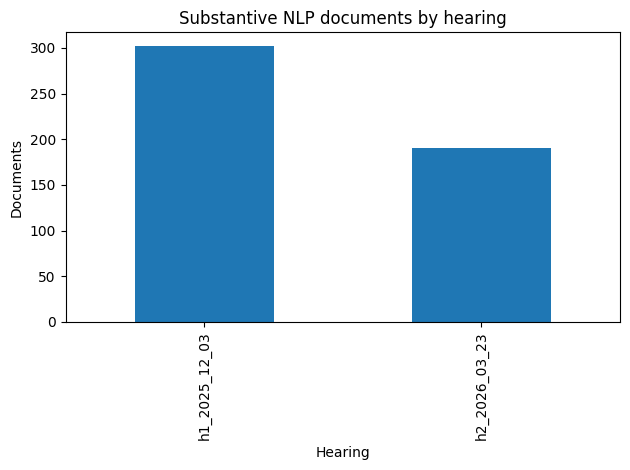

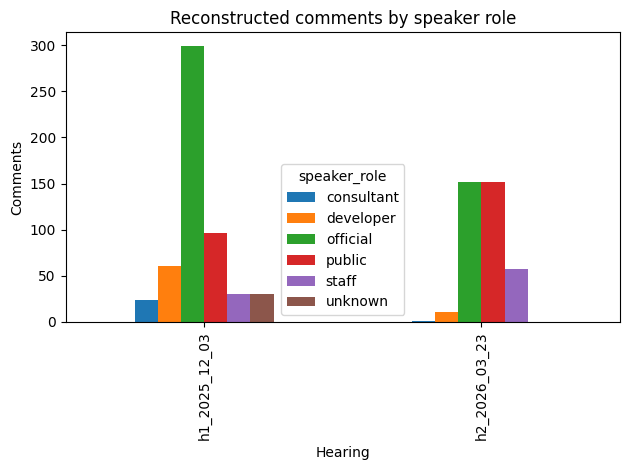

In [15]:
# One figure per chart; matplotlib defaults are retained intentionally.
ax = hearing_summary.set_index("hearing_id")["n_documents"].plot(kind="bar")
ax.set_title("Substantive NLP documents by hearing")
ax.set_xlabel("Hearing")
ax.set_ylabel("Documents")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "documents_by_hearing.png", dpi=180, bbox_inches="tight")
plt.show()

if not role_summary.empty:
    role_pivot = role_summary.pivot(index="hearing_id", columns="speaker_role", values="n_comments").fillna(0)
    ax = role_pivot.plot(kind="bar")
    ax.set_title("Reconstructed comments by speaker role")
    ax.set_xlabel("Hearing")
    ax.set_ylabel("Comments")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "comments_by_role.png", dpi=180, bbox_inches="tight")
    plt.show()

### 7A. Analyze each hearing by speaker type
Uses included reconstructed comments, independently of `ANALYSIS_CORPUS`. Reports participation, word shares, and question prevalence; exports a summary and a comment-level audit. Complete the speaker crosswalk to identify roles. Unknown and mixed roles remain separate. Counts are descriptive of hearing participation.


Data-center hearing — December 3, 2025 — h1_2025_12_03


,speaker_type,n_comments,total_words,median_comment_words,question_comments,distinct_named_speakers,distinct_single_clusters,comments_without_single_name,comment_share_pct,word_share_pct,question_comment_pct
3,public,96,15120,91.5,42,0,22,96,17.78,35.56,43.75
2,official,299,12120,17.0,139,0,15,299,55.37,28.51,46.49
1,developer,61,7479,57.0,13,0,3,61,11.30,17.59,21.31
0,consultant,24,5015,65.5,13,0,2,24,4.44,11.80,54.17
4,staff,30,2022,21.0,2,0,3,30,5.56,4.76,6.67
5,unknown,30,762,3.0,2,0,3,30,5.56,1.79,6.67



Data-center hearing — March 23, 2026 — h2_2026_03_23


,speaker_type,n_comments,total_words,median_comment_words,question_comments,distinct_named_speakers,distinct_single_clusters,comments_without_single_name,comment_share_pct,word_share_pct,question_comment_pct
9,public,152,24777,116.0,64,0,67,152,40.75,75.49,42.11
8,official,152,3639,10.5,20,0,8,152,40.75,11.09,13.16
7,developer,11,3374,32.0,3,0,2,11,2.95,10.28,27.27
6,consultant,1,544,544.0,1,0,1,1,0.27,1.66,100.00
10,staff,57,488,2.0,20,0,1,57,15.28,1.49,35.09


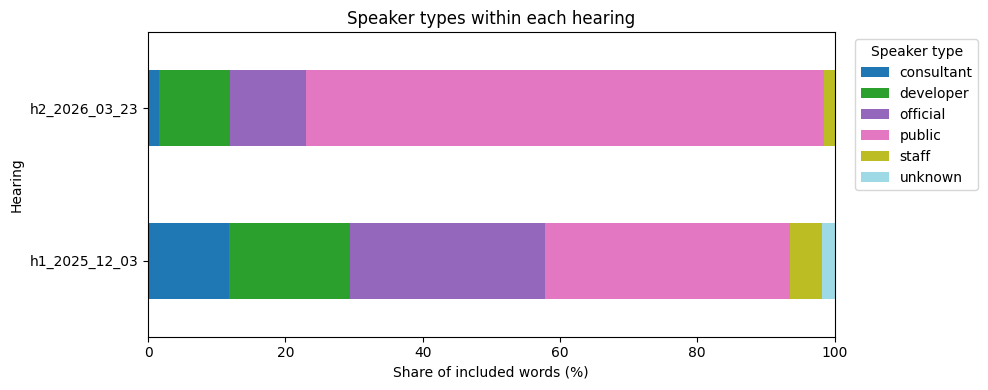

Scope: included nonprocedural comments
Comment and word shares use each hearing's total; question percentages use each role's comments.
Questions are text-based flags, not human-coded questions or project stance.
Named-speaker counts require consistent names; diarization clusters are not verified people.
Review unknown/mixed roles in the annotation sheets before interpreting role differences.


In [16]:
# Analyze each hearing by speaker type. Run after Section 7.
# Edit speaker_crosswalk.csv / turn_review.csv, then rerun Sections 4–7
# and this cell to incorporate revised role assignments.
INCLUDE_PROCEDURAL_BY_ROLE = False

role_comments = comments.loc[comments["include"].fillna(False)].copy()
if not INCLUDE_PROCEDURAL_BY_ROLE:
    role_comments = role_comments.loc[~role_comments["is_procedural"].fillna(False)].copy()

# Keep mixed and unknown attribution explicit; never infer a role from sentiment.
role_comments["speaker_type"] = (
    role_comments["speaker_role"].fillna("").astype(str).str.strip().str.lower()
    .replace({"": "unknown"})
)
role_comments.loc[
    role_comments["speaker_type"].str.contains("|", regex=False), "speaker_type"
] = "mixed / review"
role_comments["word_count"] = role_comments["analysis_text"].fillna("").str.findall(r"\b\w+\b").str.len()
role_comments["question_flag"] = role_comments["analysis_text"].fillna("").map(question_count).gt(0)

# Named people and anonymous diarization clusters are separate measures.
# Blank names must not be counted as one real speaker, and clusters are not people.
role_comments["named_speaker"] = role_comments["speaker_name"].fillna("").str.strip()
role_comments.loc[
    role_comments["named_speaker"].str.lower().isin(["", "unknown", "unknown speaker", "nan", "none"])
    | role_comments["named_speaker"].str.contains("|", regex=False), "named_speaker"
] = pd.NA
role_comments["single_cluster"] = role_comments["speaker_cluster"].fillna("").str.strip()
role_comments.loc[
    role_comments["single_cluster"].str.lower().isin(["", "unknown", "nan", "none"])
    | role_comments["single_cluster"].str.contains("|", regex=False), "single_cluster"
] = pd.NA

if role_comments.empty:
    print("No included comments in this scope. Review include/procedural annotations.")
    speaker_type_summary = pd.DataFrame()
else:
    speaker_type_summary = (
        role_comments.groupby(["hearing_id", "speaker_type"], dropna=False)
        .agg(n_comments=("comment_id", "size"),
             total_words=("word_count", "sum"),
             median_comment_words=("word_count", "median"),
             question_comments=("question_flag", "sum"),
             distinct_named_speakers=("named_speaker", "nunique"),
             distinct_single_clusters=("single_cluster", "nunique"),
             comments_without_single_name=("named_speaker", lambda s: int(s.isna().sum())))
        .reset_index()
    )
    for count_col, share_col in [("n_comments", "comment_share_pct"), ("total_words", "word_share_pct")]:
        denominator = speaker_type_summary.groupby("hearing_id")[count_col].transform("sum")
        speaker_type_summary[share_col] = 100 * speaker_type_summary[count_col] / denominator.replace(0, np.nan)
    speaker_type_summary["question_comment_pct"] = (
        100 * speaker_type_summary["question_comments"] / speaker_type_summary["n_comments"]
    )
    speaker_type_summary = speaker_type_summary.merge(
        hearing_manifest[["hearing_id", "title"]].drop_duplicates("hearing_id"),
        on="hearing_id", how="left", validate="many_to_one"
    ).sort_values(["hearing_id", "total_words"], ascending=[True, False])
    save_table(speaker_type_summary, "09a_speaker_type_by_hearing")
    save_table(role_comments[["hearing_id", "comment_id", "speaker_type", "speaker_name",
                              "speaker_cluster", "start_timestamp", "word_count", "question_flag",
                              "analysis_text"]], "09b_speaker_type_comment_audit")

    for hid, table in speaker_type_summary.groupby("hearing_id", sort=False):
        print("\n" + str(table["title"].iloc[0]) + " — " + str(hid))
        display(table.drop(columns=["hearing_id", "title"]).round(2))

    # Within-hearing percentages make hearings of different lengths comparable.
    role_word_shares = speaker_type_summary.pivot(
        index="hearing_id", columns="speaker_type", values="word_share_pct"
    ).fillna(0)
    ax = role_word_shares.plot(kind="barh", stacked=True, figsize=(10, 4), colormap="tab20")
    ax.set(xlabel="Share of included words (%)", ylabel="Hearing",
           title="Speaker types within each hearing", xlim=(0, 100))
    ax.legend(title="Speaker type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "speaker_type_word_shares_by_hearing.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Scope:", "all included comments" if INCLUDE_PROCEDURAL_BY_ROLE else "included nonprocedural comments")
    print("Comment and word shares use each hearing's total; question percentages use each role's comments.")
    print("Questions are text-based flags, not human-coded questions or project stance.")
    print("Named-speaker counts require consistent names; diarization clusters are not verified people.")
    if role_comments["speaker_type"].isin(["unknown", "mixed / review"]).any():
        print("Review unknown/mixed roles in the annotation sheets before interpreting role differences.")


## 8. Text preparation, n-grams, and TF-IDF

The cleaned text is used only for vector-based NLP. Raw and corrected transcripts remain untouched. The custom stopword list removes generic data-center terms and speech fillers that otherwise dominate every topic. Review this list before interpreting results.

In [17]:
PROJECT_STOPWORDS = {
    "cyrusone",
}
CUSTOM_STOPWORDS = set(ENGLISH_STOP_WORDS) | {
    "data", "center", "centers", "centre", "centres", "server", "servers", "farm",
    "um", "uh", "yeah", "okay", "ok", "gonna", "wanna",
} | PROJECT_STOPWORDS


def normalize_for_nlp(text: str) -> str:
    text = str(text).lower()
    text = text.replace("’", "'").replace("–", "-").replace("—", "-")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b\d+(?:[.,]\d+)?\b", " ", text)
    text = re.sub(r"[^a-z\s'-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


corpus["clean_text"] = corpus["text"].map(normalize_for_nlp)
corpus = corpus[corpus["clean_text"].str.len().gt(0)].copy().reset_index(drop=True)

(LOGS_DIR / "custom_stopwords.json").write_text(
    json.dumps(sorted(CUSTOM_STOPWORDS), indent=2), encoding="utf-8"
)


def adaptive_min_df(n_docs: int) -> int:
    if n_docs < 20:
        return 1
    if n_docs < 100:
        return 2
    return max(2, int(round(0.01 * n_docs)))


def top_ngrams(df: pd.DataFrame, top_n: int = 60) -> tuple[pd.DataFrame, CountVectorizer]:
    min_df = adaptive_min_df(len(df))
    vec = CountVectorizer(
        stop_words=sorted(CUSTOM_STOPWORDS),
        ngram_range=(1, 2),
        min_df=min_df,
        max_df=0.95,
        max_features=20_000,
    )
    X = vec.fit_transform(df["clean_text"])
    terms = np.array(vec.get_feature_names_out())
    counts = np.asarray(X.sum(axis=0)).ravel()
    table = (
        pd.DataFrame({"term": terms, "count": counts})
        .sort_values(["count", "term"], ascending=[False, True])
        .head(top_n)
        .reset_index(drop=True)
    )
    return table, vec


top_terms, count_vectorizer = top_ngrams(corpus)
save_table(top_terms, "10_top_unigrams_bigrams")
display(top_terms.head(40))

,term,count
0,going,321
1,county,294
2,just,285
3,know,276
4,board,214
5,people,208
6,want,206
7,don,199
8,ve,198
9,like,193


### 8A. Exhaustive n-gram inventory and browser

The `top_ngrams` table above is intentionally selective: it removes stopwords, applies document-frequency cutoffs, caps the vocabulary, and displays only the leading terms. This section creates a separate **exhaustive inventory within a chosen n-gram range**.

The default range is unigrams through trigrams. The inventory:

- keeps every observed term (`min_df=1`, no `max_df` exclusion, and no feature cap);
- preserves stopwords and generic project language, then flags them rather than deleting them;
- constructs n-grams within sentence boundaries, reducing accidental phrases that cross from one sentence into the next;
- reports total counts, document frequency, document share, frequency per million n-grams of the same order, and rank;
- exports overall, hearing-level long, and hearing-level wide tables;
- includes a small search helper for inspecting terms interactively.

“Exhaustive” here means every observed n-gram of the configured orders. Set `FULL_NGRAM_RANGE = (1, 4)` to add four-grams, but expect a substantially larger table and many one-off transcription fragments.


In [18]:
FULL_NGRAM_RANGE = (1, 3)
FULL_NGRAM_TEXT_COL = "text"
FULL_NGRAM_GROUP_COL = "hearing_id"

# Retain words, contractions/hyphenated words, numbers, percentages, and compact
# number-unit forms such as 100mw. URLs are removed before tokenization.
FULL_NGRAM_TOKEN_RE = re.compile(
    r"[a-z]+(?:['-][a-z]+)*|\d+(?:[.,]\d+)*(?:%|[a-z]+)?",
    flags=re.IGNORECASE,
)


def inventory_tokens(text: str) -> list[str]:
    """Tokenize raw transcript text for the exhaustive lexical inventory."""
    text = str(text or "").lower()
    text = text.replace("’", "'").replace("–", "-").replace("—", "-")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    return FULL_NGRAM_TOKEN_RE.findall(text)


def make_contiguous_ngram_analyzer(
    ngram_range: tuple[int, int] = (1, 3),
):
    """Return a CountVectorizer analyzer that does not cross sentence boundaries."""
    min_n, max_n = ngram_range
    if min_n < 1 or max_n < min_n:
        raise ValueError(f"Invalid ngram_range={ngram_range!r}")

    def analyzer(text: str):
        sentences = sentence_split(str(text)) or [str(text)]
        for sentence in sentences:
            tokens = inventory_tokens(sentence)
            for n in range(min_n, max_n + 1):
                if len(tokens) < n:
                    continue
                for start in range(len(tokens) - n + 1):
                    yield " ".join(tokens[start:start + n])

    return analyzer


def summarize_ngram_scope(
    X_scope,
    term_metadata: pd.DataFrame,
    scope_type: str,
    scope_value: str,
    n_documents: int,
) -> pd.DataFrame:
    """Summarize a document-term count matrix for one corpus scope."""
    counts = np.asarray(X_scope.sum(axis=0)).ravel().astype(np.int64)
    document_frequency = np.asarray((X_scope > 0).sum(axis=0)).ravel().astype(np.int64)
    active = counts > 0

    table = term_metadata.loc[active].copy()
    table["scope_type"] = scope_type
    table["scope_value"] = str(scope_value)
    table["count"] = counts[active]
    table["document_frequency"] = document_frequency[active]
    table["n_documents_in_scope"] = int(n_documents)
    table["document_share"] = table["document_frequency"] / max(int(n_documents), 1)

    denominators = table.groupby("ngram_n")["count"].transform("sum")
    table["occurrences_per_million_same_order"] = (
        table["count"] / denominators.replace(0, np.nan) * 1_000_000
    )

    table = table.sort_values(
        ["ngram_n", "count", "document_frequency", "term"],
        ascending=[True, False, False, True],
    ).reset_index(drop=True)
    table["rank_within_scope_and_order"] = (
        table.groupby("ngram_n", sort=False).cumcount() + 1
    )
    return table


def build_full_ngram_inventory(
    df: pd.DataFrame,
    text_col: str = "text",
    group_col: str = "hearing_id",
    ngram_range: tuple[int, int] = (1, 3),
):
    """Build exhaustive overall and group-level n-gram tables."""
    missing = {text_col, group_col} - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns for n-gram inventory: {sorted(missing)}")
    if df.empty:
        raise ValueError("Cannot build an n-gram inventory from an empty dataframe.")

    analyzer = make_contiguous_ngram_analyzer(ngram_range)
    vectorizer = CountVectorizer(
        analyzer=analyzer,
        lowercase=False,
        min_df=1,
        max_df=1.0,
        max_features=None,
        dtype=np.int64,
    )
    X = vectorizer.fit_transform(df[text_col].fillna("").astype(str))
    terms = np.asarray(vectorizer.get_feature_names_out(), dtype=object)

    token_lists = [term.split() for term in terms]
    english_stopwords = set(ENGLISH_STOP_WORDS)
    custom_stopwords = set(CUSTOM_STOPWORDS)
    term_metadata = pd.DataFrame({
        "term": terms,
        "ngram_n": [len(tokens) for tokens in token_lists],
        "contains_number": [any(any(ch.isdigit() for ch in token) for token in tokens) for tokens in token_lists],
        "contains_english_stopword": [any(token in english_stopwords for token in tokens) for tokens in token_lists],
        "contains_custom_stopword": [any(token in custom_stopwords for token in tokens) for tokens in token_lists],
        "all_tokens_custom_stopwords": [all(token in custom_stopwords for token in tokens) for tokens in token_lists],
    })

    frames = [
        summarize_ngram_scope(
            X,
            term_metadata,
            scope_type="overall",
            scope_value="all_hearings",
            n_documents=len(df),
        )
    ]

    # df.groupby(...).indices returns positional row indices, which can index X directly.
    for group_value, positions in df.groupby(group_col, sort=False).indices.items():
        positions = np.asarray(positions, dtype=int)
        frames.append(
            summarize_ngram_scope(
                X[positions],
                term_metadata,
                scope_type=group_col,
                scope_value=str(group_value),
                n_documents=len(positions),
            )
        )

    inventory = pd.concat(frames, ignore_index=True)
    inventory = inventory[[
        "scope_type", "scope_value", "ngram_n", "term", "count",
        "document_frequency", "document_share",
        "occurrences_per_million_same_order", "rank_within_scope_and_order",
        "n_documents_in_scope", "contains_number", "contains_english_stopword",
        "contains_custom_stopword", "all_tokens_custom_stopwords",
    ]]
    return inventory, vectorizer, X


full_ngram_inventory, full_ngram_vectorizer, X_full_ngrams = build_full_ngram_inventory(
    corpus,
    text_col=FULL_NGRAM_TEXT_COL,
    group_col=FULL_NGRAM_GROUP_COL,
    ngram_range=FULL_NGRAM_RANGE,
)

full_ngram_overall = full_ngram_inventory[
    full_ngram_inventory["scope_type"].eq("overall")
].copy()
full_ngram_by_hearing = full_ngram_inventory[
    full_ngram_inventory["scope_type"].eq(FULL_NGRAM_GROUP_COL)
].copy()

# A wide count table is convenient for side-by-side hearing comparisons.
full_ngram_counts_wide = (
    full_ngram_by_hearing.pivot_table(
        index=["ngram_n", "term"],
        columns="scope_value",
        values="count",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)
full_ngram_counts_wide.columns.name = None
full_ngram_counts_wide = full_ngram_counts_wide.merge(
    full_ngram_overall[["ngram_n", "term", "count"]].rename(
        columns={"count": "count_all_hearings"}
    ),
    on=["ngram_n", "term"],
    how="left",
)

save_table(full_ngram_overall, "10a_full_ngram_overall")
save_table(full_ngram_by_hearing, "10b_full_ngram_by_hearing")
save_table(full_ngram_counts_wide, "10c_full_ngram_counts_wide_by_hearing")

ngram_inventory_summary = (
    full_ngram_overall.groupby("ngram_n", as_index=False)
    .agg(
        unique_terms=("term", "size"),
        total_occurrences=("count", "sum"),
        one_off_terms=("count", lambda s: int(s.eq(1).sum())),
        median_document_frequency=("document_frequency", "median"),
    )
)
display(ngram_inventory_summary)
display(
    full_ngram_overall.groupby("ngram_n", group_keys=False).head(25)[[
        "ngram_n", "term", "count", "document_frequency", "document_share",
        "occurrences_per_million_same_order",
    ]]
)


,ngram_n,unique_terms,total_occurrences,one_off_terms,median_document_frequency
0,1,5881,70004,2716,1.0
1,2,32566,65191,24542,1.0
2,3,51171,60649,46485,1.0


,ngram_n,term,count,document_frequency,document_share,occurrences_per_million_same_order
0,1,the,3133,424,0.861789,44754.585452
1,1,to,2503,413,0.839431,35755.099709
2,1,and,2054,370,0.752033,29341.180504
3,1,that,1777,361,0.733740,25384.263756
4,1,of,1503,336,0.682927,21470.201703
...,...,...,...,...,...,...
38467,3,we need to,21,18,0.036585,346.254679
38468,3,i just want,21,17,0.034553,346.254679
38469,3,county board members,21,16,0.032520,346.254679
38470,3,of sangamon county,20,18,0.036585,329.766361


In [19]:
def browse_ngrams(
    table: pd.DataFrame = full_ngram_inventory,
    query: str = "",
    ngram_n: int | None = None,
    scope_value: str = "all_hearings",
    min_count: int = 1,
    regex: bool = False,
    exclude_all_stopword_terms: bool = False,
    limit: int = 200,
) -> pd.DataFrame:
    """Search the exhaustive table without modifying the saved inventory."""
    view = table[
        table["scope_value"].eq(scope_value)
        & table["count"].ge(min_count)
    ].copy()

    if ngram_n is not None:
        view = view[view["ngram_n"].eq(int(ngram_n))]
    if exclude_all_stopword_terms:
        view = view[~view["all_tokens_custom_stopwords"]]
    if query:
        pattern = query if regex else re.escape(query)
        view = view[view["term"].str.contains(pattern, case=False, regex=True, na=False)]

    return (
        view.sort_values(
            ["count", "document_frequency", "ngram_n", "term"],
            ascending=[False, False, True, True],
        )
        .head(limit)
        .reset_index(drop=True)
    )


# Edit these values and rerun this cell to explore the vocabulary.
NGRAM_QUERY = ""              # Examples: "water", "tax", r"\btrust\b"
NGRAM_ORDER = None            # 1, 2, 3, or None for all configured orders
NGRAM_SCOPE = "all_hearings" # Or a hearing_id such as "h1_2025_12_03"
NGRAM_MIN_COUNT = 1
NGRAM_REGEX = False

ngram_view = browse_ngrams(
    query=NGRAM_QUERY,
    ngram_n=NGRAM_ORDER,
    scope_value=NGRAM_SCOPE,
    min_count=NGRAM_MIN_COUNT,
    regex=NGRAM_REGEX,
    limit=200,
)
display(ngram_view)


,scope_type,scope_value,ngram_n,term,count,document_frequency,document_share,occurrences_per_million_same_order,rank_within_scope_and_order,n_documents_in_scope,contains_number,contains_english_stopword,contains_custom_stopword,all_tokens_custom_stopwords
0,overall,all_hearings,1,the,3133,424,0.861789,44754.585452,1,492,False,True,True,True
1,overall,all_hearings,1,to,2503,413,0.839431,35755.099709,2,492,False,True,True,True
2,overall,all_hearings,1,and,2054,370,0.752033,29341.180504,3,492,False,True,True,True
3,overall,all_hearings,1,that,1777,361,0.733740,25384.263756,4,492,False,True,True,True
4,overall,all_hearings,1,of,1503,336,0.682927,21470.201703,5,492,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,overall,all_hearings,2,name is,65,64,0.130081,997.070148,41,492,False,True,True,True
196,overall,all_hearings,1,sure,65,53,0.107724,928.518370,154,492,False,False,False,False
197,overall,all_hearings,2,about the,65,53,0.107724,997.070148,42,492,False,True,True,True
198,overall,all_hearings,1,i've,65,51,0.103659,928.518370,155,492,False,False,False,False


In [20]:
def top_tfidf_by_group(
    df: pd.DataFrame,
    group_col: str,
    top_n: int = 25,
) -> tuple[pd.DataFrame, TfidfVectorizer]:
    min_df = adaptive_min_df(len(df))
    vec = TfidfVectorizer(
        stop_words=sorted(CUSTOM_STOPWORDS),
        ngram_range=(1, 2),
        min_df=min_df,
        max_df=0.95,
        max_features=20_000,
        sublinear_tf=True,
    )
    X = vec.fit_transform(df["clean_text"])
    terms = np.array(vec.get_feature_names_out())
    rows = []
    for group_value, indices in df.groupby(group_col, sort=False).groups.items():
        positions = df.index.get_indexer(indices)
        mean_score = np.asarray(X[positions].mean(axis=0)).ravel()
        top = mean_score.argsort()[-top_n:][::-1]
        for rank, term_id in enumerate(top, 1):
            rows.append({
                group_col: group_value,
                "rank": rank,
                "term": terms[term_id],
                "mean_tfidf": mean_score[term_id],
            })
    return pd.DataFrame(rows), vec


tfidf_hearing, tfidf_vectorizer = top_tfidf_by_group(corpus, "hearing_id")
save_table(tfidf_hearing, "11_top_tfidf_by_hearing")
display(tfidf_hearing.groupby("hearing_id", group_keys=False).head(15))

,hearing_id,rank,term,mean_tfidf
0,h1_2025_12_03,1,going,0.034022
1,h1_2025_12_03,2,just,0.033978
2,h1_2025_12_03,3,know,0.032341
3,h1_2025_12_03,4,board,0.031776
4,h1_2025_12_03,5,want,0.029230
5,h1_2025_12_03,6,think,0.029156
6,h1_2025_12_03,7,question,0.029043
7,h1_2025_12_03,8,time,0.028393
8,h1_2025_12_03,9,right,0.027620
9,h1_2025_12_03,10,thank,0.027309


## 9. Distinctive language: weighted log odds

TF-IDF identifies characteristic terms, but it does not directly compare the two hearings. Weighted log odds estimates which words or phrases are disproportionately frequent in one hearing versus the other while stabilizing rare counts with an informative prior.

Positive `z_score` values favor the first hearing in `KEYNESS_GROUPS`; negative values favor the second.

In [21]:
def weighted_log_odds(
    df: pd.DataFrame,
    group_col: str,
    group_a: str,
    group_b: str,
    prior_strength: float = 100.0,
    max_features: int = 15_000,
) -> pd.DataFrame:
    subset = df[df[group_col].isin([group_a, group_b])].copy()
    if subset[group_col].nunique() != 2:
        raise ValueError("Both comparison groups must be present.")

    vec = CountVectorizer(
        stop_words=sorted(CUSTOM_STOPWORDS),
        ngram_range=(1, 2),
        min_df=1,
        max_df=1.0,
        max_features=max_features,
    )
    X = vec.fit_transform(subset["clean_text"])
    terms = np.array(vec.get_feature_names_out())
    mask_a = subset[group_col].eq(group_a).to_numpy()
    mask_b = subset[group_col].eq(group_b).to_numpy()
    y_a = np.asarray(X[mask_a].sum(axis=0)).ravel().astype(float)
    y_b = np.asarray(X[mask_b].sum(axis=0)).ravel().astype(float)

    pooled = y_a + y_b
    pooled_total = pooled.sum()
    prior_prob = (pooled + 1.0) / (pooled_total + len(pooled))
    alpha = prior_strength * prior_prob
    alpha_0 = alpha.sum()

    n_a = y_a.sum()
    n_b = y_b.sum()
    eps = 1e-12
    delta = (
        np.log((y_a + alpha + eps) / (n_a + alpha_0 - y_a - alpha + eps))
        - np.log((y_b + alpha + eps) / (n_b + alpha_0 - y_b - alpha + eps))
    )
    variance = 1.0 / (y_a + alpha + eps) + 1.0 / (y_b + alpha + eps)
    z = delta / np.sqrt(variance)

    return (
        pd.DataFrame({
            "term": terms,
            f"count_{group_a}": y_a.astype(int),
            f"count_{group_b}": y_b.astype(int),
            "log_odds_difference": delta,
            "z_score": z,
        })
        .sort_values("z_score", ascending=False)
        .reset_index(drop=True)
    )


hearing_order = [h for h in hearing_manifest["hearing_id"] if h in set(corpus["hearing_id"])]
if len(hearing_order) >= 2:
    KEYNESS_GROUPS = hearing_order[:2]
    keyness = weighted_log_odds(
        corpus, "hearing_id", KEYNESS_GROUPS[0], KEYNESS_GROUPS[1]
    )
    save_table(keyness, "12_weighted_log_odds_between_hearings")
    print("Terms favoring", KEYNESS_GROUPS[0])
    display(keyness.head(25))
    print("Terms favoring", KEYNESS_GROUPS[1])
    display(keyness.tail(25).sort_values("z_score"))
else:
    keyness = pd.DataFrame()
    print("Weighted log odds requires two loaded hearings.")

Terms favoring h1_2025_12_03


,term,count_h1_2025_12_03,count_h2_2026_03_23,log_odds_difference,z_score
0,question,63,12,1.443858,4.605852
1,mean,57,9,1.629410,4.568473
2,questions,53,10,1.452907,4.234323
3,capacity,44,7,1.621457,4.007217
4,supply,39,3,2.336283,3.944114
5,energy,54,14,1.137599,3.806756
6,projects,36,3,2.257816,3.797164
7,power,57,16,1.058713,3.754646
8,demand,29,3,2.045290,3.401574
9,megawatts,28,4,1.727164,3.251688


Terms favoring h2_2026_03_23


,term,count_h1_2025_12_03,count_h2_2026_03_23,log_odds_difference,z_score
14999,health,6,55,-2.410035,-5.650895
14998,vote,9,48,-1.874707,-5.185992
14997,noise,22,58,-1.175157,-4.705627
14996,sangamon,37,76,-0.927085,-4.634968
14995,sangamon county,32,69,-0.975267,-4.570375
14994,resolution,4,33,-2.305074,-4.385980
14993,air,3,32,-2.557690,-4.276166
14992,union,18,47,-1.165169,-4.214574
14991,care,4,30,-2.210909,-4.181623
14990,live,10,33,-1.397546,-3.883880
